### 📌 Cell 1 – Imports & Device Config

In [1]:
import pandas as pd
import numpy as np
import torch 
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import optuna

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed
torch.manual_seed(42)


Using device: cuda


### 📌 Cell 2 – Load Dataset & Visualization

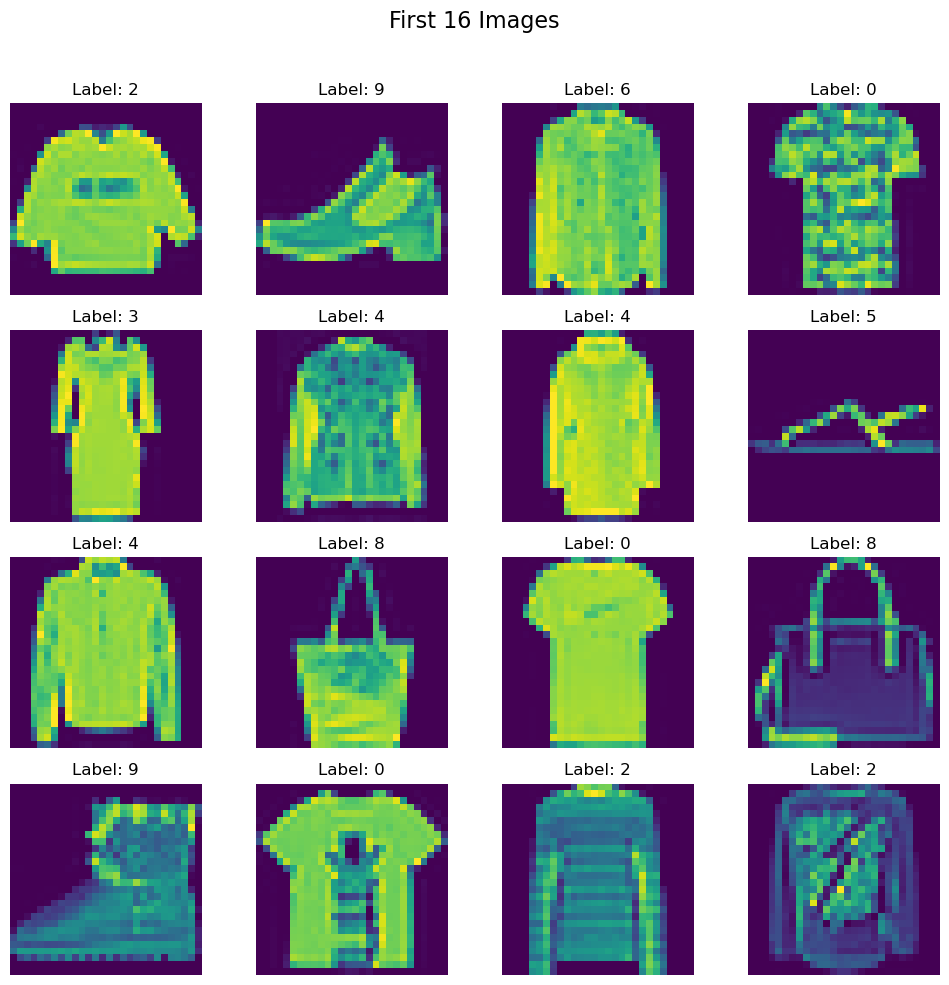

In [3]:
# Load data
df = pd.read_csv("archive/fashion-mnist_train.csv")
df.head()

# Create a 4x4 grid to visualize images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i, 0]}")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### 📌 Cell 3 – Train/Test Split + Scaling

In [4]:
x = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Scale features
x_train = x_train / 255.0
x_test = x_test / 255.0


### 📌 Cell 4 – Custom Dataset & DataLoaders

In [5]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

# Create dataset objects
train_dataset = CustomDataset(x_train, y_train)
test_dataset = CustomDataset(x_test, y_test)

# Base data loaders
base_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
base_test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)


### 📌 Cell 5 – Flexible Neural Network

In [7]:
class MyNN(nn.Module):
    def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate=0.3):
        super().__init__()
        layers = []
        layers.append(nn.Linear(input_dim, neurons_per_layer))
        layers.append(nn.BatchNorm1d(neurons_per_layer))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout_rate))

        for i in range(num_hidden_layers - 1):
            layers.append(nn.Linear(neurons_per_layer, neurons_per_layer))
            layers.append(nn.BatchNorm1d(neurons_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))

        layers.append(nn.Linear(neurons_per_layer, output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


### 📌 Cell 6 – Optuna Objective Function

In [9]:
def objective(trial):
    # Hyperparameters
    num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5)
    neurons_per_layer = trial.suggest_int("neurons_per_layer", 8, 128, step=8)
    epochs = trial.suggest_int("epochs", 10, 50, step=10)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
    optimizer_name = trial.suggest_categorical("optimizer", ['Adam', 'SGD', 'RMSprop'])
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

    # Data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

    # Model
    model = MyNN(784, 10, num_hidden_layers, neurons_per_layer, dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # Training
    for epoch in range(epochs):
        model.train()
        total_epoch_loss = 0
        for batch_features, batch_labels in train_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_epoch_loss += loss.item()

        if epoch % 10 == 0:
            print(f"Trial {trial.number}, Epoch {epoch+1}/{epochs}, Avg Loss: {total_epoch_loss/len(train_loader):.4f}")

    # Evaluation
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

    accuracy = correct / total
    print(f"Trial {trial.number} Accuracy: {accuracy:.4f}")
    return accuracy


📌 Cell 7 – Run Optuna Study

In [11]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)  # Try more later

print("Best Trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value:.4f}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-09-22 23:23:37,936] A new study created in memory with name: no-name-abd88e98-071f-41f4-898e-b2c1888cceaa


Trial 0, Epoch 1/40, Avg Loss: 0.7193
Trial 0, Epoch 11/40, Avg Loss: 0.5276
Trial 0, Epoch 21/40, Avg Loss: 0.5109
Trial 0, Epoch 31/40, Avg Loss: 0.5215


[I 2025-09-22 23:30:29,429] Trial 0 finished with value: 0.8590833333333333 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 96, 'epochs': 40, 'learning_rate': 0.0035748825972113578, 'dropout_rate': 0.2, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.00015773302243101553}. Best is trial 0 with value: 0.8590833333333333.


Trial 0 Accuracy: 0.8591
Trial 1, Epoch 1/50, Avg Loss: 0.6836
Trial 1, Epoch 11/50, Avg Loss: 0.4592
Trial 1, Epoch 21/50, Avg Loss: 0.4443
Trial 1, Epoch 31/50, Avg Loss: 0.4468
Trial 1, Epoch 41/50, Avg Loss: 0.4424


[I 2025-09-22 23:34:59,384] Trial 1 finished with value: 0.867 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 88, 'epochs': 50, 'learning_rate': 0.008130726832376107, 'dropout_rate': 0.2, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 3.0149663352922236e-05}. Best is trial 1 with value: 0.867.


...

Trial 2 Accuracy: 0.4527
Trial 3, Epoch 1/20, Avg Loss: 1.9082
Trial 3, Epoch 11/20, Avg Loss: 1.9691


[I 2025-09-22 23:45:36,465] Trial 3 finished with value: 0.20475 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 120, 'epochs': 20, 'learning_rate': 0.0368430539018394, 'dropout_rate': 0.5, 'batch_size': 16, 'optimizer': 'RMSprop', 'weight_decay': 0.0007334769207913323}. Best is trial 1 with value: 0.867.


Trial 3 Accuracy: 0.2047
Trial 4, Epoch 1/20, Avg Loss: 0.7217
Trial 4, Epoch 11/20, Avg Loss: 0.4254


[I 2025-09-22 23:47:31,806] Trial 4 finished with value: 0.8835 and parameters: {'num_hidden_layers': 2, 'neurons_per_layer': 120, 'epochs': 20, 'learning_rate': 0.0007708250768678911, 'dropout_rate': 0.5, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 3.344321222310584e-05}. Best is trial 4 with value: 0.8835.


Trial 4 Accuracy: 0.8835
Best Trial:
  Accuracy: 0.8835
  Params:
    num_hidden_layers: 2
    neurons_per_layer: 120
    epochs: 20
    learning_rate: 0.0007708250768678911
    dropout_rate: 0.5
    batch_size: 32
    optimizer: Adam
    weight_decay: 3.344321222310584e-05


In [15]:
study.best_value

0.8835

In [16]:
study.best_params

{'num_hidden_layers': 2,
 'neurons_per_layer': 120,
 'epochs': 20,
 'learning_rate': 0.0007708250768678911,
 'dropout_rate': 0.5,
 'batch_size': 32,
 'optimizer': 'Adam',
 'weight_decay': 3.344321222310584e-05}

## 📌 Cell 8 – Train Final Model with Best Params

In [12]:
print("\nTraining final model with best hyperparameters...")
best_params = study.best_params

final_train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True, pin_memory=True)
final_test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False, pin_memory=True)

final_model = MyNN(784, 10, best_params['num_hidden_layers'], best_params['neurons_per_layer'], best_params['dropout_rate']).to(device)

criterion = nn.CrossEntropyLoss()
if best_params['optimizer'] == 'Adam':
    optimizer = optim.Adam(final_model.parameters(), lr=best_params['learning_rate'], weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == 'SGD':
    optimizer = optim.SGD(final_model.parameters(), lr=best_params['learning_rate'], weight_decay=best_params['weight_decay'])
else:
    optimizer = optim.RMSprop(final_model.parameters(), lr=best_params['learning_rate'], weight_decay=best_params['weight_decay'])



Training final model with best hyperparameters...


### 📌 Cell 9 – Final Training & Accuracy Check

In [13]:
final_epochs = best_params['epochs'] * 2
train_losses = []

for epoch in range(final_epochs):
    final_model.train()
    total_epoch_loss = 0
    for batch_features, batch_labels in final_train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = final_model(batch_features)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_epoch_loss += loss.item()

    avg_loss = total_epoch_loss / len(final_train_loader)
    train_losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Final Model Epoch {epoch+1}/{final_epochs}, Avg Loss: {avg_loss:.4f}")

# Final evaluation
final_model.eval()

# Test accuracy
total, correct = 0, 0
with torch.no_grad():
    for batch_features, batch_labels in final_test_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = final_model(batch_features)
        _, predicted = torch.max(outputs, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

test_accuracy = correct / total

# Train accuracy
total_train, correct_train = 0, 0
with torch.no_grad():
    for batch_features, batch_labels in final_train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = final_model(batch_features)
        _, predicted = torch.max(outputs, 1)
        total_train += batch_labels.size(0)
        correct_train += (predicted == batch_labels).sum().item()

train_accuracy = correct_train / total_train

print(f"\nFinal Results:")
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Difference: {abs(train_accuracy - test_accuracy):.4f}")


Final Model Epoch 1/40, Avg Loss: 0.7290
Final Model Epoch 11/40, Avg Loss: 0.4253
Final Model Epoch 21/40, Avg Loss: 0.3894
Final Model Epoch 31/40, Avg Loss: 0.3727

Final Results:
Train Accuracy: 0.9124
Test Accuracy: 0.8851
Difference: 0.0273


### |📌 Cell 10 – Plot & Save Model

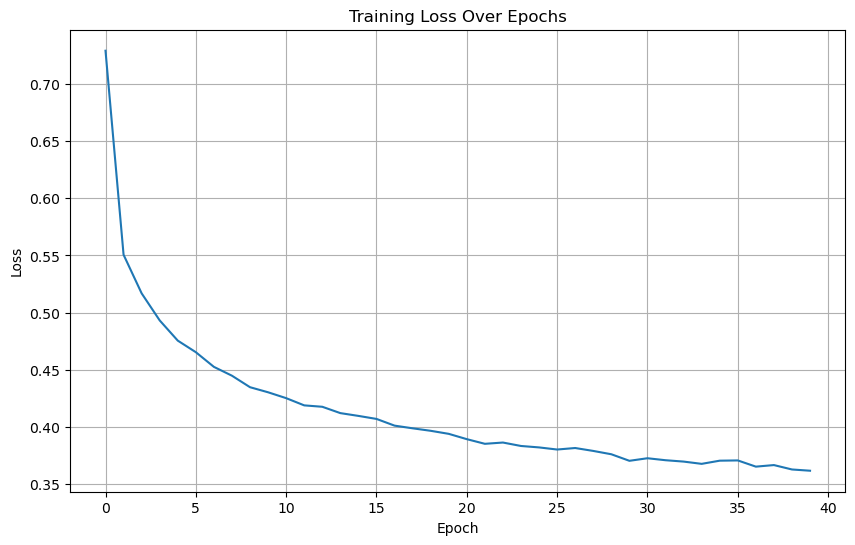

Model saved as 'fashion_mnist_model.pth'


In [14]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

torch.save(final_model.state_dict(), 'fashion_mnist_model.pth')
print("Model saved as 'fashion_mnist_model.pth'")
